In [14]:
%pip install ultralytics opencv-python matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\vaide\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


In [16]:
# model = YOLO("yolov8n.pt")  # lightweight & fast


In [17]:
# model.train(
#     data="data.yaml",
#     epochs=50,
#     imgsz=640,
#     batch=16
# )


## ready made model

In [18]:
model = YOLO("construction-ppe/runs/detect/train2/weights/best.pt")


In [19]:
image = cv2.imread("construction-ppe/images/test/image1.jpeg")
results = model(image)[0]



0: 640x640 1 helmet, 1 gloves, 1 vest, 1 Person, 110.3ms
Speed: 2.7ms preprocess, 110.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


In [20]:
classes = model.names

persons = []
ppe_positive = {"helmet": [], "gloves": [], "vest": []}
ppe_negative = {"no_helmet": [], "no_gloves": []}

# Store confidence also
for box in results.boxes:
    cls_name = classes[int(box.cls[0])]
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])

    if cls_name == "Person":
        persons.append((x1, y1, x2, y2))
    elif cls_name in ppe_positive:
        ppe_positive[cls_name].append((x1, y1, x2, y2, conf))
    elif cls_name in ppe_negative:
        ppe_negative[cls_name].append((x1, y1, x2, y2, conf))

# Check overlap
def is_inside(ppe_box, person_box):
    px1, py1, px2, py2 = person_box
    x1, y1, x2, y2 = ppe_box[:4]
    return px1 < x1 < px2 and py1 < y1 < py2

# Process each person
for (px1, py1, px2, py2) in persons:

    status = {
        "helmet": False,
        "gloves": False,
        "vest": False
    }

    confidences = []

    # Positive PPE detection
    for item in ppe_positive:
        for box in ppe_positive[item]:
            if is_inside(box, (px1, py1, px2, py2)):
                status[item] = True
                confidences.append(box[4])

    # Negative PPE overrides
    for neg in ppe_negative:
        for box in ppe_negative[neg]:
            if is_inside(box, (px1, py1, px2, py2)):
                if neg == "no_helmet":
                    status["helmet"] = False
                elif neg == "no_gloves":
                    status["gloves"] = False

    # Confidence calculation
    avg_conf = sum(confidences) / len(confidences) if confidences else 0.0

    # Final decision
    if all(status.values()):
        color = (0, 255, 0)   # GREEN
        label = f"PPE OK ({avg_conf:.2f})"
    else:
        color = (0, 0, 255)   # RED
        label = f"PPE MISSING ({avg_conf:.2f})"

    cv2.rectangle(image, (px1, py1), (px2, py2), color, 3)
    cv2.putText(
        image, label,
        (px1, py1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        color,
        2
    )


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

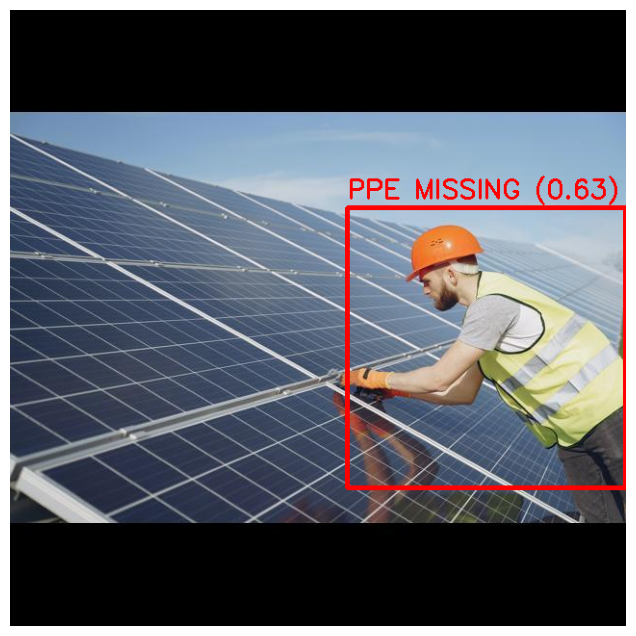

In [21]:
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")


In [22]:
from ultralytics import YOLO
import cv2

# Load trained model
model = YOLO("construction-ppe/runs/detect/train2/weights/best.pt")

cap = cv2.VideoCapture(0)  # 0 = webcam

classes = model.names

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, conf=0.4)[0]

    persons = []
    ppe_positive = {"helmet": [], "gloves": [], "vest": []}
    ppe_negative = {"no_helmet": [], "no_gloves": []}

    # Collect detections
    for box in results.boxes:
        cls_name = classes[int(box.cls[0])]
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        if cls_name == "Person":
            persons.append((x1, y1, x2, y2))
        elif cls_name in ppe_positive:
            ppe_positive[cls_name].append((x1, y1, x2, y2, conf))
        elif cls_name in ppe_negative:
            ppe_negative[cls_name].append((x1, y1, x2, y2, conf))

    # Check overlap
    def is_inside(item_box, person_box):
        px1, py1, px2, py2 = person_box
        x1, y1, x2, y2 = item_box[:4]
        return px1 < x1 < px2 and py1 < y1 < py2

    # Process each person
    for (px1, py1, px2, py2) in persons:

        status = {"helmet": False, "gloves": False, "vest": False}
        confidences = []

        for item in ppe_positive:
            for box in ppe_positive[item]:
                if is_inside(box, (px1, py1, px2, py2)):
                    status[item] = True
                    confidences.append(box[4])

        for neg in ppe_negative:
            for box in ppe_negative[neg]:
                if is_inside(box, (px1, py1, px2, py2)):
                    if neg == "no_helmet":
                        status["helmet"] = False
                    elif neg == "no_gloves":
                        status["gloves"] = False

        avg_conf = sum(confidences) / len(confidences) if confidences else 0.0

        if all(status.values()):
            color = (0, 255, 0)
            label = f"PPE OK ({avg_conf:.2f})"
        else:
            color = (0, 0, 255)
            label = f"PPE MISSING ({avg_conf:.2f})"

        cv2.rectangle(frame, (px1, py1), (px2, py2), color, 3)
        cv2.putText(
            frame, label,
            (px1, py1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

    cv2.imshow("Live PPE Detection", frame)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 480x640 1 boots, 1 none, 2 Persons, 93.1ms
Speed: 3.1ms preprocess, 93.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 boots, 2 Persons, 110.8ms
Speed: 1.8ms preprocess, 110.8ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 vest, 1 boots, 2 Persons, 88.1ms
Speed: 2.5ms preprocess, 88.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 vest, 1 boots, 2 Persons, 79.2ms
Speed: 2.5ms preprocess, 79.2ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 vest, 2 Persons, 80.3ms
Speed: 2.3ms preprocess, 80.3ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 vest, 2 Persons, 80.1ms
Speed: 1.8ms preprocess, 80.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 vest, 2 Persons, 84.2ms
Speed: 1.8ms preprocess, 84.2ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 vest, 2 Per